# מבוא ללמידה עמוקה – מטלת בית 2  
## Afeka College of Engineering  
### Semester B, 2026

**סטודנטים:**  
- אביעד צפרי – 322281452  
- דוד אזימוב – 205697592  

---

## Question 1

Suppose you are training a neural network for binary classification with a sigmoid activation function in the output layer and Binary Cross-Entropy (BCE) as the loss function.

- Derive the gradient of the BCE loss function with respect to the weights of the output layer.
- Explain how the gradient is influenced by the magnitude of the predictions (close to 0 or 1).

## Answer 1

In binary classification, the output layer produces a probability prediction:

$$
\hat{y} = \sigma(z)
$$

where

$$
z = W^T h + b
$$

Here:

- $h$ is the vector of activations from the previous layer,
- $W$ is the vector of output-layer weights,
- $b$ is the output-layer bias,
- $\hat{y}$ is the predicted probability,
- $y \in \{0,1\}$ is the true label.

The sigmoid function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The Binary Cross-Entropy loss for one training example is:

$$
L = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

We want to compute:

$$
\frac{\partial L}{\partial W}
$$

Using the chain rule:

$$
\frac{\partial L}{\partial W}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial z}
\cdot
\frac{\partial z}{\partial W}
$$

First:

$$
\frac{\partial L}{\partial \hat{y}}
=
-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}
=
\frac{\hat{y}-y}{\hat{y}(1-\hat{y})}
$$

The derivative of the sigmoid function is:

$$
\frac{\partial \hat{y}}{\partial z}
=
\hat{y}(1-\hat{y})
$$

Therefore:

$$
\frac{\partial L}{\partial z}
=
\frac{\hat{y}-y}{\hat{y}(1-\hat{y})}
\cdot
\hat{y}(1-\hat{y})
=
\hat{y} - y
$$

Since:

$$
z = W^T h + b
$$

we have:

$$
\frac{\partial z}{\partial W} = h
$$

Therefore, the gradient of the BCE loss with respect to the output-layer weights is:

$$
\boxed{
\frac{\partial L}{\partial W}
=
(\hat{y} - y)h
}
$$

For a batch of $n$ samples, if the loss is averaged over the batch, the gradient is:

$$
\boxed{
\nabla_W L
=
\frac{1}{n}H^T(\hat{y}-y)
}
$$

where $H$ is the matrix of previous-layer activations, and $(\hat{y}-y)$ is the vector of prediction errors.

The gradient with respect to the bias is:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\hat{y} - y
}
$$

or for a batch:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)
}
$$

### Influence of predictions close to 0 or 1

The important result is that the output-layer error term is:

$$
\hat{y} - y
$$

Therefore, the gradient depends directly on the difference between the predicted probability and the true label.

If the prediction is correct and confident, the gradient is small.

For example, if:

$$
y = 1, \quad \hat{y} \approx 1
$$

then:

$$
\hat{y} - y \approx 0
$$

So the weight update is very small.

Similarly, if:

$$
y = 0, \quad \hat{y} \approx 0
$$

then again:

$$
\hat{y} - y \approx 0
$$

So the model barely changes, because it already predicts correctly.

However, if the prediction is wrong and confident, the gradient becomes large in magnitude.

For example, if:

$$
y = 1, \quad \hat{y} \approx 0
$$

then:

$$
\hat{y} - y \approx -1
$$

This creates a strong negative gradient, causing the update to increase the output logit $z$ and push the prediction closer to 1.

If:

$$
y = 0, \quad \hat{y} \approx 1
$$

then:

$$
\hat{y} - y \approx 1
$$

This creates a strong positive gradient, causing the update to decrease the output logit $z$ and push the prediction closer to 0.

Thus, BCE strongly penalizes confident wrong predictions, while giving almost no update for confident correct predictions. This is one reason BCE is suitable for binary classification with a sigmoid output layer.

---

## Question 2

Given the following confusion matrix for a multi-class classification problem with three classes (A, B, and C):

|  | Predicted A | Predicted B | Predicted C |
|---|---:|---:|---:|
| Actual A | 50 | 5 | 10 |
| Actual B | 7 | 60 | 8 |
| Actual C | 4 | 6 | 80 |

- Calculate the accuracy, precision, recall, and F1-score for each class.
- Provide the overall accuracy and the weighted average F1-score for the model.

## Answer 2

For each class, we treat the class as "positive" and all other classes as "negative".

The formulas are:

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

$$
F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
= \frac{2TP}{2TP + FP + FN}
$$

The total number of samples: $ 50 + 5 + 10 + 7 + 60 + 8 + 4 + 6 + 80 = 230 $

The number of correct predictions is the sum of the diagonal: $ 50 + 60 + 80 = 190 $

Therefore, the overall accuracy is:

$$
Accuracy = \frac{190}{230} = 0.8261
=
\boxed{82.61\%}
$$

### Class A

For class A:

$$
TP_A = 50
$$

$$
FP_A = 7 + 4 = 11
$$

$$
FN_A = 5 + 10 = 15
$$

Therefore:

$$
Precision_A = \frac{50}{50+11} = \frac{50}{61} = 0.8197
$$

$$
Recall_A = \frac{50}{50+15} = \frac{50}{65} = 0.7692
$$

$$
F1_A = \frac{2 \cdot 50}{2 \cdot 50 + 11 + 15}
= \frac{100}{126}
= 0.7937
$$

### Class B

For class B:

$$
TP_B = 60
$$

$$
FP_B = 5 + 6 = 11
$$

$$
FN_B = 7 + 8 = 15
$$

Therefore:

$$
Precision_B = \frac{60}{60+11} = \frac{60}{71} = 0.8451
$$

$$
Recall_B = \frac{60}{60+15} = \frac{60}{75} = 0.8000
$$

$$
F1_B = \frac{2 \cdot 60}{2 \cdot 60 + 11 + 15}
= \frac{120}{146}
= 0.8219
$$

### Class C

For class C:

$$
TP_C = 80
$$

$$
FP_C = 10 + 8 = 18
$$

$$
FN_C = 4 + 6 = 10
$$

Therefore:

$$
Precision_C = \frac{80}{80+18} = \frac{80}{98} = 0.8163
$$

$$
Recall_C = \frac{80}{80+10} = \frac{80}{90} = 0.8889
$$

$$
F1_C = \frac{2 \cdot 80}{2 \cdot 80 + 18 + 10}
= \frac{160}{188}
= 0.8511
$$

### Summary table

| Class | Support | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| A | 65 | 0.8197 | 0.7692 | 0.7937 |
| B | 75 | 0.8451 | 0.8000 | 0.8219 |
| C | 90 | 0.8163 | 0.8889 | 0.8511 |

The weighted average F1-score is calculated according to the support of each class:

$$
Weighted \ F1 =
\frac{65 \cdot F1_A + 75 \cdot F1_B + 90 \cdot F1_C}{230}
$$

Substituting the values:

$$
Weighted \ F1 =
\frac{65 \cdot 0.7937 + 75 \cdot 0.8219 + 90 \cdot 0.8511}{230}
$$

$$
Weighted \ F1 = 0.8253
$$

Therefore:

$$
\boxed{Weighted \ Average \ F1 = 82.53\%}
$$

Final results:

- Overall accuracy: $82.61\%$
- Weighted average F1-score: $82.53\%$

Lets verify with code:

In [36]:
import numpy as np
import pandas as pd

cm = np.array([
    [50, 5, 10],
    [7, 60, 8],
    [4, 6, 80]
])

classes = ["A", "B", "C"]

results = []

for i, cls in enumerate(classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    support = cm[i, :].sum()
    
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)
    
    results.append([cls, support, precision, recall, f1])

df = pd.DataFrame(
    results,
    columns=["Class", "Support", "Precision", "Recall", "F1-score"]
)

overall_accuracy = np.trace(cm) / cm.sum()
weighted_f1 = np.average(df["F1-score"], weights=df["Support"])

display(df)

print(f"Overall Accuracy: {overall_accuracy:.4f} = {overall_accuracy * 100:.2f}%")
print(f"Weighted Average F1-score: {weighted_f1:.4f} = {weighted_f1 * 100:.2f}%")

,Class,Support,Precision,Recall,F1-score
0,A,65,0.819672,0.769231,0.793651
1,B,75,0.845070,0.800000,0.821918
2,C,90,0.816327,0.888889,0.851064


Overall Accuracy: 0.8261 = 82.61%
Weighted Average F1-score: 0.8253 = 82.53%


---

## Question 3

Write a Python program to:

- Build and train a fully connected neural network for binary classification on the `Breast Cancer Wisconsin` dataset.
- Use ReLU activation in the hidden layers and sigmoid activation in the output layer.
- Evaluate the model using accuracy and the confusion matrix.
- Plot the training and validation loss over epochs.

### Answer 3

#### **Breast Cancer Wisconsin Dataset Description**

The `Breast Cancer Wisconsin` dataset is a classic binary classification dataset available through `scikit-learn`.

Dataset reference:  
**[scikit-learn `load_breast_cancer` dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)**

The dataset contains **569 observations** and **30 numerical predictor variables**, where each observation corresponds to a tumor sample.

**Response variable:**
- `target`: The tumor diagnosis class.

**Target classes:**
- `0`: malignant
- `1`: benign

**Predictor variables:**

The 30 predictors are real-valued positive features computed from digitized images of breast mass cell nuclei.  
They include measurements such as:

- `mean radius`
- `mean texture`
- `mean perimeter`
- `mean area`
- `mean smoothness`
- `mean compactness`
- `mean concavity`
- `mean concave points`
- `mean symmetry`
- `mean fractal dimension`

and their corresponding standard error and worst-value versions.

Because the features are measured on different numerical scales, the input variables will be standardized before training the neural network.

Since this is a binary classification problem, the neural network will use:

- ReLU activation functions in the hidden layers
- Sigmoid activation function in the output layer
- Binary Cross-Entropy as the loss function
- Accuracy and confusion matrix for evaluation

#### **Data Analysis**

##### Installations and imports

In [ ]:
# If TensorFlow is not installed, uncomment and run this line:
%pip install tensorflow scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
# Common imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# TensorFlow imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Remove warnings imports
import os
import warnings
import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hides TensorFlow INFO and WARNING C++ logs
warnings.filterwarnings("ignore")        # hides regular Python warnings
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# For reproducible results
np.random.seed(42)
tf.random.set_seed(42)

##### Part 1: Load and inspect the dataset

First, we load the Breast Cancer Wisconsin dataset from `scikit-learn`.

The predictor matrix is stored in `X`, and the target vector is stored in `y`.

In [39]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

df = data.frame

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target names:", data.target_names)
print()

print("Class distribution:")
print(y.map({0: "malignant", 1: "benign"}).value_counts())

df.head()

Dataset shape: (569, 31)
Feature matrix shape: (569, 30)
Target vector shape: (569,)
Target names: ['malignant' 'benign']

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


##### Part 2: Split the data into training and testing sets

The data is divided into a training set and a testing set.

The training set is used to train the neural network, while the test set is kept aside for final evaluation.

We use `stratify=y` to preserve the original class proportions in both sets.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 30)
Test set shape: (114, 30)


##### Part 3: Standardize the predictor variables

Neural networks are sensitive to the scale of the input features.

Therefore, we standardize the features so that each feature has approximately mean 0 and standard deviation 1.

The scaler is fitted only on the training data, and then applied to both the training and test data.

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

Scaled training data shape: (455, 30)
Scaled test data shape: (114, 30)


##### Part 4: Build the fully connected neural network

The neural network is fully connected, meaning that each neuron in one layer is connected to all neurons in the next layer.

The architecture is:

- Input layer with 30 input features
- First hidden layer with 32 neurons and ReLU activation
- Second hidden layer with 16 neurons and ReLU activation
- Output layer with 1 neuron and sigmoid activation

The sigmoid output gives a probability between 0 and 1.

In [42]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

##### Part 5: Train the model

The model is trained using the standardized training data.

A validation split of 20% is used, meaning that 20% of the training data is used as validation data during training.

The validation loss helps us monitor whether the model generalizes well or begins to overfit.

In [43]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5522 - loss: 0.6851 - val_accuracy: 0.8132 - val_loss: 0.5159
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9203 - loss: 0.3982 - val_accuracy: 0.9451 - val_loss: 0.3360
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9368 - loss: 0.2616 - val_accuracy: 0.9670 - val_loss: 0.2369
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9451 - loss: 0.1885 - val_accuracy: 0.9670 - val_loss: 0.1745
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9533 - loss: 0.1446 - val_accuracy: 0.9890 - val_loss: 0.1364
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9725 - loss: 0.1175 - val_accuracy: 0.9890 - val_loss: 0.1127
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.1009 - val_accuracy: 0.9890 - val_loss: 0.0971
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0898 - val_accuracy: 0.9890 - v

##### Part 6: Evaluate the model using accuracy and confusion matrix

The trained model outputs probabilities.

To convert probabilities into class predictions, we use a threshold of 0.5:

- If the predicted probability is greater than or equal to 0.5, the predicted class is `1`, meaning benign.
- If the predicted probability is less than 0.5, the predicted class is `0`, meaning malignant.

The model is evaluated using:

- Test accuracy
- Confusion matrix
- Classification report

In [44]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Accuracy score:", round(accuracy, 4))
print()

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test loss: 0.1607
Test accuracy: 0.9561
Accuracy score: 0.9561

Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [45]:
# Helper function:
# --------------------------------------------------------
# Improved confusion matrix visualization (general version)
import seaborn as sns

def plot_confusion_matrix_custom(
    cm,
    labels=None,
    cmap="YlGnBu",
    normalize=None,
    orientation="sklearn",
    title="Confusion Matrix"
):
    """
    General confusion matrix heatmap.

    Parameters
    ----------
    cm : array-like or pandas DataFrame
        Confusion matrix.

    labels : list, optional
        Class labels in display order.

    cmap : str
        Matplotlib / seaborn colormap.

    normalize : None, "true", "pred", or "all"
        - None: show raw counts
        - "true": normalize by actual class rows
        - "pred": normalize by predicted class columns
        - "all": normalize by total number of samples

    title : str
        Plot title.

    # Possible colormaps (cmap) for heatmaps:
    # --------------------------------------
    # Clean: "YlGnBu", "Blues", "BuGn", "Greens", "Purples", "Oranges"
    # High contrast (strong emphasis): "YlOrRd", "OrRd", "Reds", "rocket"
    # Scientific / colorblind-friendly: "viridis", "plasma", "inferno", "magma", "cividis"
    # Fun / full-spectrum: "Spectral", "cool", "summer", "autumn"
    # Reverse any colormap: Add "_r"   e.g., "YlGnBu_r", "Blues_r", "viridis_r"
    """

    # Convert DataFrame to numeric array
    if isinstance(cm, pd.DataFrame):
        numeric_cm = cm.values

        if labels is None:
            if orientation == "sklearn":
                labels = list(cm.index)
            elif orientation == "islp":
                labels = list(cm.columns)
    else:
        numeric_cm = np.array(cm)

        if labels is None:
            labels = [str(i) for i in range(numeric_cm.shape[0])]

    # Convert ISLP orientation to standard orientation
    # Standard display: rows = Actual, columns = Predicted
    if orientation == "islp":
        numeric_cm = numeric_cm.T

    numeric_cm = numeric_cm.astype(float)

    # Normalize if requested
    if normalize == "true":
        numeric_cm = numeric_cm / numeric_cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    elif normalize == "pred":
        numeric_cm = numeric_cm / numeric_cm.sum(axis=0, keepdims=True)
        fmt = ".2f"
    elif normalize == "all":
        numeric_cm = numeric_cm / numeric_cm.sum()
        fmt = ".2f"
    else:
        fmt = "d"
        numeric_cm = numeric_cm.astype(int)

    # Avoid showing NaN if a row/column sum is zero
    numeric_cm = np.nan_to_num(numeric_cm)

    df_cm = pd.DataFrame(
        numeric_cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels]
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        df_cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        cbar=True
    )

    plt.title(title)
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return df_cm


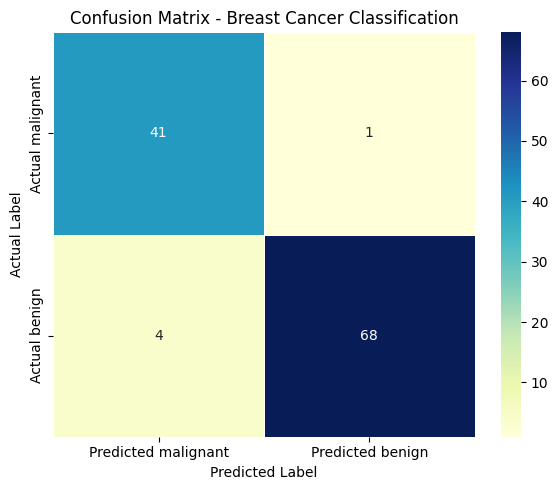

,Predicted malignant,Predicted benign
Actual malignant,41,1
Actual benign,4,68


In [46]:
cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix_custom(
    cm,
    labels=data.target_names,
    cmap="YlGnBu",
    orientation="sklearn",
    title="Confusion Matrix - Breast Cancer Classification"
)

##### Part 7: Plot the training and validation loss over epochs

Finally, we plot the training loss and validation loss over the epochs.

This allows us to visually inspect the learning process.

If both losses decrease, the model is learning well.

If the training loss decreases while the validation loss increases, this may indicate overfitting.

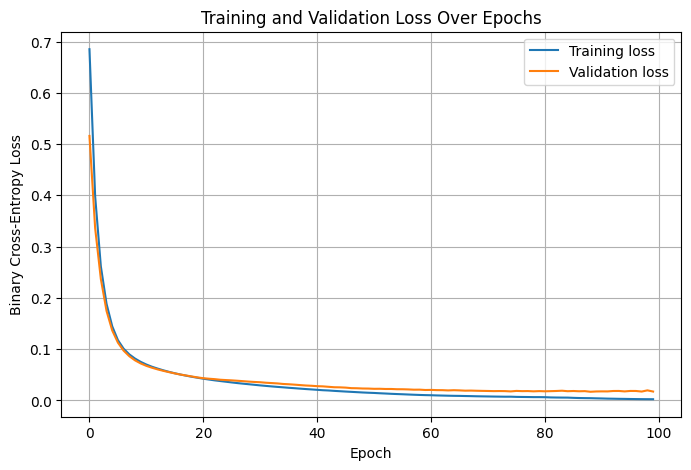

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)

plt.show()

#### **Conclusions**

The fully connected neural network achieved strong performance on the Breast Cancer Wisconsin binary classification task.

The final test accuracy was:

$$
Accuracy = 0.9561
$$

meaning that the model correctly classified approximately **95.61%** of the test samples.

The confusion matrix was:

| Actual / Predicted | Predicted malignant | Predicted benign |
|---|---:|---:|
| Actual malignant | 41 | 1 |
| Actual benign | 4 | 68 |

From the confusion matrix, we can see that the model correctly classified:

- **41 malignant tumors** as malignant
- **68 benign tumors** as benign

The model made only **5 mistakes** out of 114 test samples:

- **1 malignant tumor** was incorrectly classified as benign
- **4 benign tumors** were incorrectly classified as malignant

This is an important distinction. In a medical classification problem, predicting a malignant tumor as benign is usually the more serious error, because it may cause a dangerous case to be missed. In this run, the model made only one such error.

The classification report also shows strong performance:

- Malignant precision: **0.91**
- Malignant recall: **0.98**
- Malignant F1-score: **0.94**
- Benign precision: **0.99**
- Benign recall: **0.94**
- Benign F1-score: **0.96**
- Weighted average F1-score: **0.96**

The malignant recall is especially high:

$$
Recall_{malignant} = 0.98
$$

This means that the model successfully identified almost all malignant cases in the test set.

The training and validation loss curves both decreased rapidly during the first epochs and then stabilized at low values. The training loss continued decreasing slightly below the validation loss, but the validation loss remained low and stable. Therefore, there is no strong indication of severe overfitting.

Overall, the neural network learned the classification problem well. The combination of high test accuracy, high F1-scores, and stable validation loss suggests that the model generalizes well to unseen data.

---

### Question 4

Construct a dataset containing 20 rows (objects) and 3 features (columns) filled with random numbers in the range [0, 1]. Randomly apply labels (0 or 1) to each row.

- Write python program to build and train fully connected NN for binary classification on this dataset.
- Evaluate the accuracy of the model and plot the loss over epochs.
- Change the dataset to demonstrate the problem of overfitting (you can add / delete rows or change the values of the datasets add / delete columns.
- Change the dataset to demonstrate the problem of underfitting (you can add / delete rows or change the values of the dataset or add / delete columns.
- Discuss how the model complexity contributes to the overfitting. Demonstrate your claims
- Compare and contrast dropout and l2 regularization in addressing overfitting. Explain scenarios where one technique might be preferred over the other.

### Answer 4

In this question, we build synthetic datasets in order to demonstrate three situations:

1. A basic binary classification neural network on a small random dataset.
2. Overfitting, where the model learns the training data very well but generalizes poorly.
3. Underfitting, where the model is too simple to learn the underlying structure of the data.

The important point is that the first dataset contains random labels. Therefore, there is no real meaningful relationship between the features and the labels. Any good training accuracy on such a dataset may simply indicate memorization rather than real learning.

#### **Data Analysis**
##### **helper functions**

In [48]:
def plot_loss(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_binary_model(model, X_test, y_test, target_names=None):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print("Accuracy:", round(acc, 4))
    print()
    print("Confusion matrix:")
    print(cm)
    print()
    
    if target_names is None:
        target_names = ["Class 0", "Class 1"]
        
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    return acc, cm

##### Part 1: Construct the basic random dataset

We first construct a dataset with:

- 20 rows
- 3 features
- Feature values sampled randomly from the range $[0,1]$
- Random binary labels, either 0 or 1

Because the labels are random, the dataset does not contain a meaningful pattern. The model may achieve some accuracy, but the result should not be interpreted as strong real learning.

In [49]:
rng = np.random.default_rng(42)

X = rng.random((20, 3))
y = rng.integers(0, 2, size=20)

df_basic = pd.DataFrame(X, columns=["Feature_1", "Feature_2", "Feature_3"])
df_basic["Label"] = y

df_basic

,Feature_1,Feature_2,Feature_3,Label
0,0.773956,0.438878,0.858598,0
1,0.697368,0.094177,0.975622,1
2,0.761140,0.786064,0.128114,1
3,0.450386,0.370798,0.926765,0
4,0.643865,0.822762,0.443414,1
5,0.227239,0.554585,0.063817,1
6,0.827631,0.631664,0.758088,0
7,0.354526,0.970698,0.893121,1
8,0.778383,0.194639,0.466721,1
9,0.043804,0.154289,0.683049,1


##### Part 2: Build and train a fully connected neural network

The model is a fully connected neural network with:

- Input layer of 3 features
- Two hidden layers with ReLU activation
- One output neuron with sigmoid activation

The sigmoid output is suitable for binary classification because it outputs a probability between 0 and 1.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

basic_model = Sequential([
    Input(shape=(3,)),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

basic_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_basic = basic_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=4,
    verbose=0
)

basic_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (888.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 148 (596.00 B)

Basic random dataset results:
Accuracy: 0.1667

Confusion matrix:
[[0 2]
 [3 1]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         2
     Class 1       0.33      0.25      0.29         4

    accuracy                           0.17         6
   macro avg       0.17      0.12      0.14         6
weighted avg       0.22      0.17      0.19         6



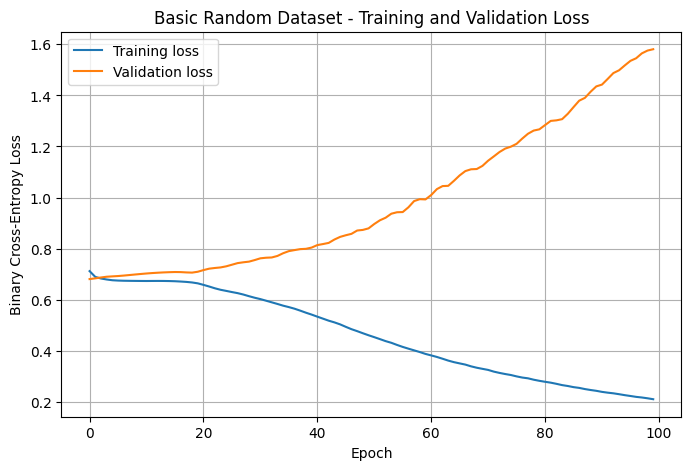

In [51]:
print("Basic random dataset results:")
evaluate_binary_model(
    basic_model,
    X_test,
    y_test,
    target_names=["Class 0", "Class 1"]
)

plot_loss(history_basic, "Basic Random Dataset - Training and Validation Loss")

##### Part 3: Change the dataset to demonstrate overfitting

To demonstrate overfitting, we change the dataset by adding many more input features while keeping the number of observations relatively small.

This creates a situation where the model has enough capacity to memorize the training data.

The changed dataset has:

- 40 rows
- 80 random features
- Random binary labels

Since the labels are random, there is no real relationship to learn. A very complex model can still memorize the training set, but it should perform poorly on validation or test data.

In [52]:
rng = np.random.default_rng(7)

X_overfit = rng.random((40, 80))
y_overfit = rng.integers(0, 2, size=40)

X_over_train, X_over_test, y_over_train, y_over_test = train_test_split(
    X_overfit,
    y_overfit,
    test_size=0.4,
    random_state=42,
    stratify=y_overfit
)

overfit_model = Sequential([
    Input(shape=(80,)),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

overfit_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_overfit = overfit_model.fit(
    X_over_train,
    y_over_train,
    validation_data=(X_over_test, y_over_test),
    epochs=300,
    batch_size=4,
    verbose=0
)

overfit_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 256)            │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,005 (750.02 KB)

 Trainable params: 64,001 (250.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 128,004 (500.02 KB)

Overfitting demonstration results:
Accuracy: 0.375

Confusion matrix:
[[4 5]
 [5 2]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.44      0.44      0.44         9
     Class 1       0.29      0.29      0.29         7

    accuracy                           0.38        16
   macro avg       0.37      0.37      0.37        16
weighted avg       0.38      0.38      0.38        16



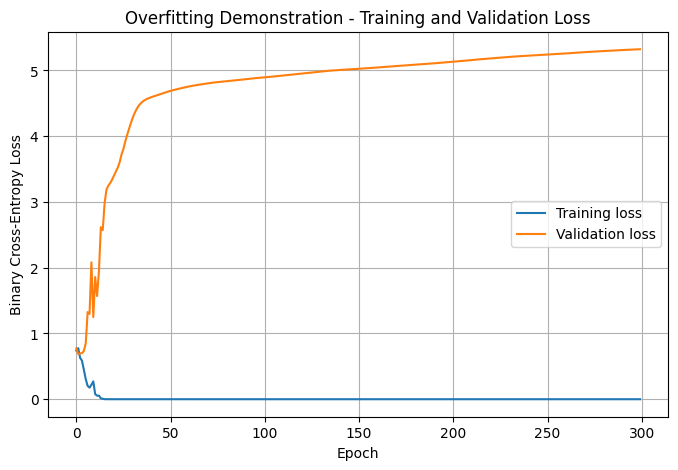

In [53]:
print("Overfitting demonstration results:")
evaluate_binary_model(
    overfit_model,
    X_over_test,
    y_over_test,
    target_names=["Class 0", "Class 1"]
)

plot_loss(history_overfit, "Overfitting Demonstration - Training and Validation Loss")

##### Overfitting explanation

Overfitting occurs when the model learns the training data too specifically, including random noise.

In this example, overfitting is encouraged by:

- A small number of rows
- A large number of features
- A very complex neural network
- Many training epochs
- Random labels with no real pattern

A typical sign of overfitting is:

- Training loss decreases strongly
- Validation loss stops improving or increases
- Training accuracy becomes high
- Validation/test accuracy remains low or unstable

This means the model memorized the training examples instead of learning a general rule.

##### Part 4: Change the dataset to demonstrate underfitting

To demonstrate underfitting, we create a dataset with a nonlinear relationship.

The label is generated using an XOR-like rule:

$$
y = 1
$$

if exactly one of the first two features is greater than 0.5, and otherwise:

$$
y = 0
$$

This creates a nonlinear classification boundary.

Then, we intentionally train a model that is too simple: a single sigmoid output neuron without hidden layers.

Such a model is essentially linear and cannot properly represent the XOR structure.

In [54]:
rng = np.random.default_rng(100)

X_underfit = rng.random((400, 3))

y_underfit = (
    (X_underfit[:, 0] > 0.5) ^ (X_underfit[:, 1] > 0.5)
).astype(int)

X_under_train, X_under_test, y_under_train, y_under_test = train_test_split(
    X_underfit,
    y_underfit,
    test_size=0.3,
    random_state=42,
    stratify=y_underfit
)

underfit_model = Sequential([
    Input(shape=(3,)),
    Dense(1, activation="sigmoid")
])

underfit_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_underfit = underfit_model.fit(
    X_under_train,
    y_under_train,
    validation_data=(X_under_test, y_under_test),
    epochs=100,
    batch_size=16,
    verbose=0
)

underfit_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

Underfitting demonstration results:
Accuracy: 0.6

Confusion matrix:
[[65  1]
 [47  7]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.58      0.98      0.73        66
     Class 1       0.88      0.13      0.23        54

    accuracy                           0.60       120
   macro avg       0.73      0.56      0.48       120
weighted avg       0.71      0.60      0.50       120



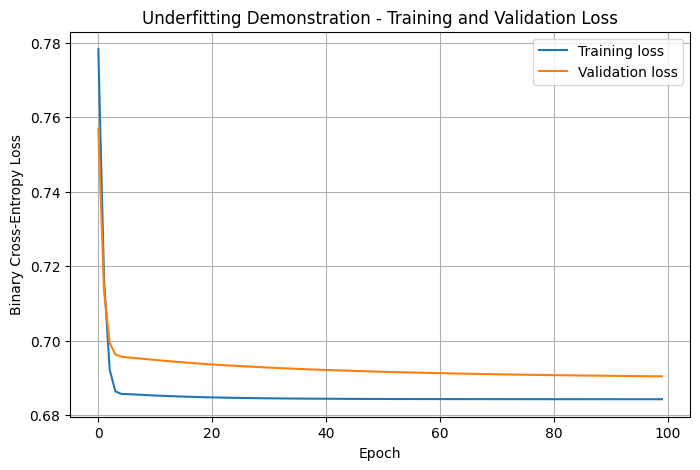

In [55]:
print("Underfitting demonstration results:")
evaluate_binary_model(
    underfit_model,
    X_under_test,
    y_under_test,
    target_names=["Class 0", "Class 1"]
)

plot_loss(history_underfit, "Underfitting Demonstration - Training and Validation Loss")

##### Underfitting explanation

Underfitting occurs when the model is too simple to capture the true structure in the data.

In this example, the data follows a nonlinear XOR-like rule, but the model has only one sigmoid output neuron and no hidden layers.

Therefore, the model can only learn a linear decision boundary.

A typical sign of underfitting is:

- Training loss remains relatively high
- Validation loss also remains high
- Training accuracy is not good
- Validation accuracy is also not good

Unlike overfitting, where the training performance is very good but validation performance is poor, underfitting gives poor performance on both training and validation data.

##### Part 5: Demonstrating how model complexity contributes to overfitting

Model complexity refers to the ability of the model to represent complicated functions.

In neural networks, complexity increases when we add:

- More hidden layers
- More neurons per layer
- More trainable parameters
- More training epochs
- Fewer regularization constraints

A complex model is not always bad. If the dataset has a real complex pattern, a larger model may be useful.

However, if the dataset is small or noisy, a complex model may memorize the training data instead of learning a general relationship. This causes overfitting.

Simple model on overfitting dataset:
Accuracy: 0.375

Confusion matrix:
[[4 5]
 [5 2]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.44      0.44      0.44         9
     Class 1       0.29      0.29      0.29         7

    accuracy                           0.38        16
   macro avg       0.37      0.37      0.37        16
weighted avg       0.38      0.38      0.38        16

Complex model on overfitting dataset:
Accuracy: 0.375

Confusion matrix:
[[4 5]
 [5 2]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.44      0.44      0.44         9
     Class 1       0.29      0.29      0.29         7

    accuracy                           0.38        16
   macro avg       0.37      0.37      0.37        16
weighted avg       0.38      0.38      0.38        16



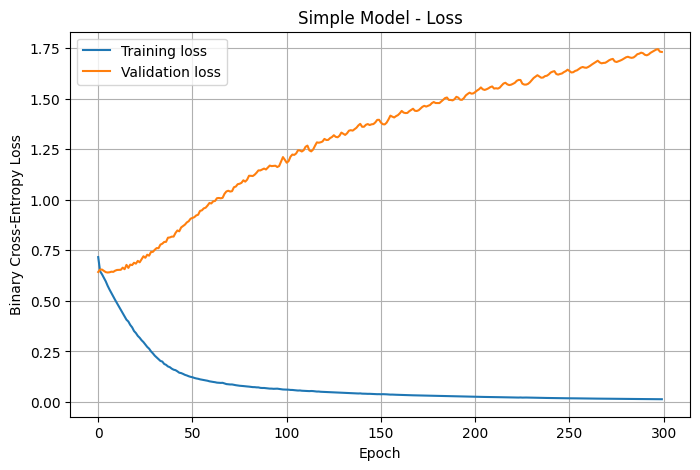

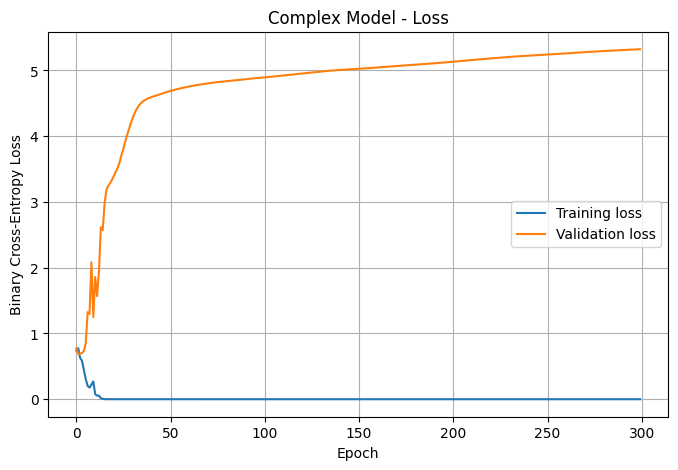

In [56]:
simple_model = Sequential([
    Input(shape=(80,)),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

simple_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_simple = simple_model.fit(
    X_over_train,
    y_over_train,
    validation_data=(X_over_test, y_over_test),
    epochs=300,
    batch_size=4,
    verbose=0
)

print("Simple model on overfitting dataset:")
simple_acc, _ = evaluate_binary_model(
    simple_model,
    X_over_test,
    y_over_test,
    target_names=["Class 0", "Class 1"]
)

print("Complex model on overfitting dataset:")
complex_acc, _ = evaluate_binary_model(
    overfit_model,
    X_over_test,
    y_over_test,
    target_names=["Class 0", "Class 1"]
)

plot_loss(history_simple, "Simple Model - Loss")
plot_loss(history_overfit, "Complex Model - Loss")

##### Part 6: Dropout and L2 regularization

Dropout and L2 regularization are two common techniques for reducing overfitting.

##### Dropout

Dropout randomly disables a fraction of neurons during training.

This prevents the model from relying too strongly on specific neurons and forces it to learn more robust patterns.

Dropout is often useful in larger neural networks with many hidden units.

##### L2 regularization

L2 regularization adds a penalty for large weights to the loss function:

$$
L_{total} = L_{BCE} + \lambda \sum_j w_j^2
$$

This encourages the model to use smaller weights and smoother decision boundaries.

L2 is often useful when we want a more stable model and when the dataset is not very large.

##### Comparison

| Technique | Main idea | Best used when |
|---|---|---|
| Dropout | Randomly disables neurons during training | The neural network is large and may rely too much on specific neurons |
| L2 regularization | Penalizes large weights | We want smoother weights and a less sensitive model |
| Dropout + L2 | Combines both effects | The model is highly complex and overfitting is severe |

Dropout is usually more aggressive because it changes the network during training.  
L2 is usually smoother because it keeps the full network active but discourages overly large weights.

Dropout model:
Accuracy: 0.375

Confusion matrix:
[[4 5]
 [5 2]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.44      0.44      0.44         9
     Class 1       0.29      0.29      0.29         7

    accuracy                           0.38        16
   macro avg       0.37      0.37      0.37        16
weighted avg       0.38      0.38      0.38        16

L2 model:
Accuracy: 0.5

Confusion matrix:
[[4 5]
 [3 4]]

Classification report:
              precision    recall  f1-score   support

     Class 0       0.57      0.44      0.50         9
     Class 1       0.44      0.57      0.50         7

    accuracy                           0.50        16
   macro avg       0.51      0.51      0.50        16
weighted avg       0.52      0.50      0.50        16



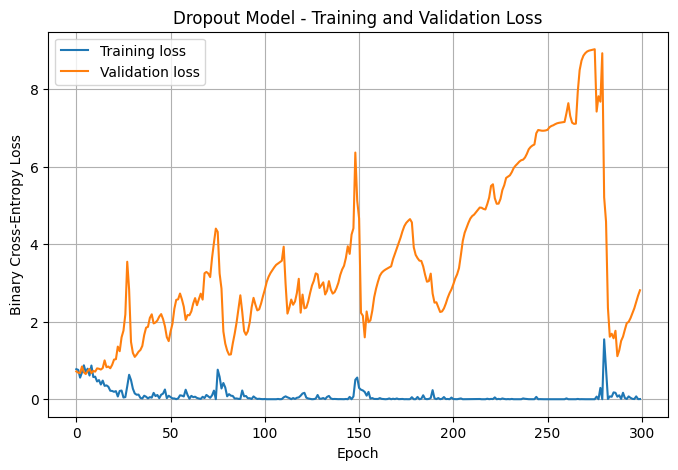

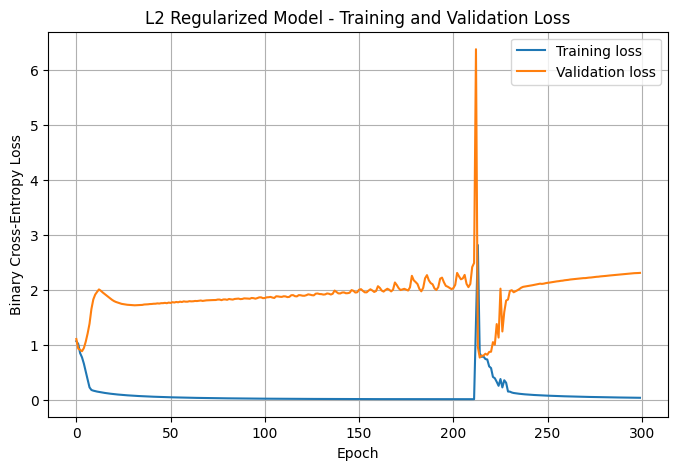

In [57]:
dropout_model = Sequential([
    Input(shape=(80,)),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_dropout = dropout_model.fit(
    X_over_train,
    y_over_train,
    validation_data=(X_over_test, y_over_test),
    epochs=300,
    batch_size=4,
    verbose=0
)


l2_model = Sequential([
    Input(shape=(80,)),
    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(1, activation="sigmoid")
])

l2_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_l2 = l2_model.fit(
    X_over_train,
    y_over_train,
    validation_data=(X_over_test, y_over_test),
    epochs=300,
    batch_size=4,
    verbose=0
)


print("Dropout model:")
dropout_acc, _ = evaluate_binary_model(
    dropout_model,
    X_over_test,
    y_over_test,
    target_names=["Class 0", "Class 1"]
)

print("L2 model:")
l2_acc, _ = evaluate_binary_model(
    l2_model,
    X_over_test,
    y_over_test,
    target_names=["Class 0", "Class 1"]
)

plot_loss(history_dropout, "Dropout Model - Training and Validation Loss")
plot_loss(history_l2, "L2 Regularized Model - Training and Validation Loss")

#### **Discussion of the Regularization Graphs**

The dropout and L2 regularization graphs show that the training loss becomes very low, while the validation loss remains much higher and unstable.

This means that the model still fits the training data much better than the validation data.

Therefore, the graphs do not show that dropout or L2 fully solved the overfitting problem. Instead, they show an important limitation: regularization can reduce overfitting, but it cannot create a real relationship when the dataset itself contains random features and random labels.

In the dropout model, the validation loss is especially unstable. This suggests that the model is still unable to generalize to unseen samples. Dropout randomly disables neurons during training, but when the labels are random, there is no true pattern to learn.

In the L2-regularized model, the validation loss is slightly smoother than in the dropout model, but it is still much higher than the training loss. This means that L2 regularization also did not solve the problem completely.

Therefore, these graphs are useful because they demonstrate that overfitting is not only a model problem. It is also a data problem. If the dataset has no meaningful relationship between features and labels, even regularized neural networks may fail to generalize.

#### **Final Conclusions**

In this question, several neural network experiments were performed in order to demonstrate basic binary classification, overfitting, underfitting, model complexity, and regularization.

First, a small synthetic dataset was constructed with **20 rows**, **3 random features**, and randomly assigned binary labels. A fully connected neural network was trained on this dataset. Since the labels were random, there was no real relationship between the input features and the target labels. Therefore, the model's accuracy on this dataset should be interpreted carefully. Any good training result may reflect memorization rather than true learning.

Next, the dataset was changed to demonstrate **overfitting**. The number of features was increased while the number of observations remained small. A complex neural network with many hidden layers and many neurons was trained on this data. This setup gave the model high capacity relative to the amount of data. As a result, the model was able to reduce the training loss strongly, but the validation loss remained much higher. This shows overfitting: the model learned the training examples too specifically and failed to generalize well to unseen data.

The overfitting experiment also demonstrates the effect of **model complexity**. A model with more layers, more neurons, and more parameters can represent more complicated functions. This can be useful when the data contains a real complex pattern. However, when the dataset is small or noisy, a highly complex model can memorize noise. In this case, increasing model complexity reduces training loss but does not necessarily improve validation performance.

Then, the dataset was changed to demonstrate **underfitting**. A nonlinear XOR-like rule was used to generate the labels, but the model was intentionally kept too simple by using only one sigmoid output neuron and no hidden layers. This model can only represent a linear decision boundary, while the dataset requires a nonlinear decision boundary. The result was poor performance on both the training and validation/test data. This demonstrates underfitting: the model was not complex enough to capture the structure of the data.

The underfitting result showed an accuracy of about **60%**, with very poor recall for class 1. This means that the model mainly predicted one class and failed to properly learn the nonlinear relationship. Unlike overfitting, where training performance is strong but validation performance is weak, underfitting produces weak performance on both training and validation data.

Finally, dropout and L2 regularization were tested as methods for addressing overfitting.

Dropout randomly disables neurons during training. This prevents the network from relying too strongly on specific neurons and can improve generalization in large neural networks.

L2 regularization adds a penalty for large weights:

$$
L_{total} = L_{BCE} + \lambda \sum_j w_j^2
$$

This encourages smaller weights and smoother decision boundaries.

However, in this experiment, both dropout and L2 regularization still produced a large gap between training loss and validation loss. This means that regularization did not fully solve the overfitting problem. The reason is that the dataset used for the overfitting demonstration had random labels and no real underlying pattern. Regularization can reduce memorization, but it cannot create useful information that does not exist in the data.

Overall, the experiments show the following:

- A small random dataset is not reliable for measuring real learning.
- A complex model trained on small or noisy data can overfit.
- A model that is too simple for a nonlinear problem can underfit.
- Increasing model complexity lowers bias but can increase variance.
- Dropout and L2 regularization can help reduce overfitting, but they cannot fix a dataset with random labels and no meaningful structure.
- Good model performance requires both an appropriate model complexity and a dataset that contains a real learnable relationship.